# 🛒 E-Commerce Customer Behavior Analysis
## CRISP-DM Methodology
---
### Step 3: Data Preparation

In this phase, we **clean, transform, and engineer features** to make the data ready for modeling.

**Objectives of this phase:**
- Handle missing values
- Handle duplicates
- Fix data types
- Encode categorical variables
- Feature engineering (create new meaningful features)
- Feature scaling & normalization
- Feature selection
- Train-test split preparation
- Save the cleaned dataset

---
## 3.1 Import Libraries & Load Data

In [1]:
# ============================
# Importing Libraries
# ============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn imports
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [2]:
# Load the original dataset
df_original = pd.read_csv('E-commerce Customer Behavior - Sheet1.csv')
print(f'✅ Original dataset loaded: {df_original.shape[0]} rows × {df_original.shape[1]} columns')

# Create a working copy (never modify the original)
df = df_original.copy()
print(f'✅ Working copy created: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Original dataset loaded: 350 rows × 11 columns
✅ Working copy created: 350 rows × 11 columns


,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.60,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.10,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.40,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.70,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.00,True,55,Unsatisfied


In [3]:
# Quick recap of data quality from Step 2
print('='*80)
print('📋 DATA QUALITY RECAP FROM STEP 2')
print('='*80)
print(f'\nShape       : {df.shape}')
print(f'Missing     : {df.isnull().sum().sum()} total missing values')
print(f'Duplicates  : {df.duplicated().sum()} full row duplicates')
print(f'\nMissing per column:')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nData Types:')
print(df.dtypes)

📋 DATA QUALITY RECAP FROM STEP 2

Shape       : (350, 11)
Missing     : 2 total missing values
Duplicates  : 0 full row duplicates

Missing per column:
Satisfaction Level    2
dtype: int64

Data Types:
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level           object
dtype: object


---
## 3.2 Handling Missing Values

### 3.2.1 Identify Missing Values

In [4]:
# Detailed missing value inspection
print('='*80)
print('🔍 MISSING VALUES — DETAILED INSPECTION')
print('='*80)

# Show all rows with missing values
missing_rows = df[df.isnull().any(axis=1)]
print(f'\nRows with missing values: {len(missing_rows)}\n')
print(missing_rows)

# Which columns have missing values?
print(f'\nColumn with missing: Satisfaction Level')
print(f'Missing count: {df["Satisfaction Level"].isnull().sum()}')
print(f'Missing percentage: {df["Satisfaction Level"].isnull().sum() / len(df) * 100:.2f}%')

🔍 MISSING VALUES — DETAILED INSPECTION

Rows with missing values: 2

     Customer ID  Gender  Age     City Membership Type  Total Spend  \
71           172  Female   37  Houston          Bronze       420.80   
143          244  Female   37  Houston          Bronze       430.80   

     Items Purchased  Average Rating  Discount Applied  \
71                 7            3.10             False   
143                7            3.40             False   

     Days Since Last Purchase Satisfaction Level  
71                         21                NaN  
143                        23                NaN  

Column with missing: Satisfaction Level
Missing count: 2
Missing percentage: 0.57%


### 3.2.2 Analyze Patterns of Missing Rows

In [5]:
# Analyze the missing rows to understand their patterns
print('='*80)
print('🔍 ANALYSIS OF ROWS WITH MISSING SATISFACTION LEVEL')
print('='*80)

for idx, row in missing_rows.iterrows():
    print(f'\n--- Customer ID: {row["Customer ID"]} (Row {idx}) ---')
    print(f'   Gender          : {row["Gender"]}')
    print(f'   Age             : {row["Age"]}')
    print(f'   City            : {row["City"]}')
    print(f'   Membership Type : {row["Membership Type"]}')
    print(f'   Total Spend     : ${row["Total Spend"]}')
    print(f'   Items Purchased : {row["Items Purchased"]}')
    print(f'   Average Rating  : {row["Average Rating"]}')
    print(f'   Discount Applied: {row["Discount Applied"]}')
    print(f'   Days Since Last : {row["Days Since Last Purchase"]}')
    
    # Find similar customers (same membership, same city)
    similar = df[
        (df['Membership Type'] == row['Membership Type']) & 
        (df['City'] == row['City']) &
        (df['Satisfaction Level'].notna())
    ]
    print(f'\n   Similar customers (same tier + city): {len(similar)}')
    if len(similar) > 0:
        print(f'   Their satisfaction distribution:')
        print(f'   {similar["Satisfaction Level"].value_counts().to_dict()}')
        print(f'   Their avg spend: ${similar["Total Spend"].mean():.2f}')
        print(f'   This customer spend: ${row["Total Spend"]}')

🔍 ANALYSIS OF ROWS WITH MISSING SATISFACTION LEVEL

--- Customer ID: 172 (Row 71) ---
   Gender          : Female
   Age             : 37
   City            : Houston
   Membership Type : Bronze
   Total Spend     : $420.8
   Items Purchased : 7
   Average Rating  : 3.1
   Discount Applied: False
   Days Since Last : 21

   Similar customers (same tier + city): 56
   Their satisfaction distribution:
   {'Neutral': 56}
   Their avg spend: $447.65
   This customer spend: $420.8

--- Customer ID: 244 (Row 143) ---
   Gender          : Female
   Age             : 37
   City            : Houston
   Membership Type : Bronze
   Total Spend     : $430.8
   Items Purchased : 7
   Average Rating  : 3.4
   Discount Applied: False
   Days Since Last : 23

   Similar customers (same tier + city): 56
   Their satisfaction distribution:
   {'Neutral': 56}
   Their avg spend: $447.65
   This customer spend: $430.8


### 3.2.3 Imputation Strategy & Execution

In [6]:
# Strategy: Use MODE imputation based on similar customer profiles
# (same Membership Type) since Membership Type is the strongest predictor

print('='*80)
print('🔧 MISSING VALUE IMPUTATION — MODE BY MEMBERSHIP TYPE')
print('='*80)

print('\nStrategy: Impute using the most common Satisfaction Level')
print('for customers with the same Membership Type\n')

# Before imputation
print('--- BEFORE Imputation ---')
print(f'Missing values: {df["Satisfaction Level"].isnull().sum()}')
print(f'Value counts:\n{df["Satisfaction Level"].value_counts()}')

# Impute each missing row
for idx, row in missing_rows.iterrows():
    membership = row['Membership Type']
    
    # Find mode of satisfaction for this membership type
    mode_val = df[df['Membership Type'] == membership]['Satisfaction Level'].mode()[0]
    
    print(f'\n   Customer {row["Customer ID"]} (Membership: {membership})')
    print(f'   → Imputed with: "{mode_val}" (mode for {membership} members)')
    
    df.loc[idx, 'Satisfaction Level'] = mode_val

# After imputation
print('\n--- AFTER Imputation ---')
print(f'Missing values: {df["Satisfaction Level"].isnull().sum()}')
print(f'Value counts:\n{df["Satisfaction Level"].value_counts()}')

🔧 MISSING VALUE IMPUTATION — MODE BY MEMBERSHIP TYPE

Strategy: Impute using the most common Satisfaction Level
for customers with the same Membership Type

--- BEFORE Imputation ---
Missing values: 2
Value counts:
Satisfaction Level
Satisfied      125
Unsatisfied    116
Neutral        107
Name: count, dtype: int64

   Customer 172 (Membership: Bronze)
   → Imputed with: "Unsatisfied" (mode for Bronze members)

   Customer 244 (Membership: Bronze)
   → Imputed with: "Unsatisfied" (mode for Bronze members)

--- AFTER Imputation ---
Missing values: 0
Value counts:
Satisfaction Level
Satisfied      125
Unsatisfied    118
Neutral        107
Name: count, dtype: int64


In [7]:
# Verify: No more missing values in the entire dataset
print('='*80)
print('✅ MISSING VALUES VERIFICATION')
print('='*80)

total_missing = df.isnull().sum().sum()
print(f'\nTotal missing values in dataset: {total_missing}')

if total_missing == 0:
    print('🎉 SUCCESS: Dataset is now 100% complete — no missing values!')
else:
    print(f'⚠️ WARNING: {total_missing} missing values still remain!')
    print(df.isnull().sum()[df.isnull().sum() > 0])

✅ MISSING VALUES VERIFICATION

Total missing values in dataset: 0
🎉 SUCCESS: Dataset is now 100% complete — no missing values!


---
## 3.3 Handling Duplicates

In [8]:
# Check for duplicates
print('='*80)
print('🔁 DUPLICATE HANDLING')
print('='*80)

# Full row duplicates
full_dups = df.duplicated().sum()
print(f'\nFull row duplicates: {full_dups}')

# Customer ID duplicates
id_dups = df['Customer ID'].duplicated().sum()
print(f'Duplicate Customer IDs: {id_dups}')

if full_dups > 0:
    print(f'\n--- Removing {full_dups} duplicate rows ---')
    df_before = len(df)
    df = df.drop_duplicates()
    print(f'Rows before: {df_before}')
    print(f'Rows after : {len(df)}')
    print(f'Removed    : {df_before - len(df)}')
else:
    print('\n✅ No full row duplicates found. No action needed.')

print(f'\nCurrent dataset shape: {df.shape}')

🔁 DUPLICATE HANDLING

Full row duplicates: 0
Duplicate Customer IDs: 0

✅ No full row duplicates found. No action needed.

Current dataset shape: (350, 11)


---
## 3.4 Data Type Corrections

In [9]:
# Check current data types
print('='*80)
print('🔧 DATA TYPE INSPECTION & CORRECTION')
print('='*80)

print('\n--- Current Data Types ---')
print(df.dtypes)

# Check Discount Applied — should it be boolean?
print(f'\nDiscount Applied unique values: {df["Discount Applied"].unique()}')
print(f'Discount Applied dtype: {df["Discount Applied"].dtype}')

🔧 DATA TYPE INSPECTION & CORRECTION

--- Current Data Types ---
Customer ID                   int64
Gender                       object
Age                           int64
City                         object
Membership Type              object
Total Spend                 float64
Items Purchased               int64
Average Rating              float64
Discount Applied               bool
Days Since Last Purchase      int64
Satisfaction Level           object
dtype: object

Discount Applied unique values: [ True False]
Discount Applied dtype: bool


In [10]:
# Convert Discount Applied to proper boolean if needed
print('--- Converting Discount Applied ---')
print(f'Before: dtype = {df["Discount Applied"].dtype}')

# If it's stored as string TRUE/FALSE
if df['Discount Applied'].dtype == 'object':
    df['Discount Applied'] = df['Discount Applied'].map({'TRUE': True, 'FALSE': False})
    print('Converted from string (TRUE/FALSE) to boolean')

# Convert to int (0/1) for easier analysis
df['Discount Applied'] = df['Discount Applied'].astype(int)
print(f'After : dtype = {df["Discount Applied"].dtype}')
print(f'Values: {df["Discount Applied"].unique()}')
print(f'  0 = No Discount, 1 = Discount Applied')

--- Converting Discount Applied ---
Before: dtype = bool
After : dtype = int64
Values: [1 0]
  0 = No Discount, 1 = Discount Applied


In [11]:
# Convert categorical columns to 'category' dtype for memory efficiency
print('\n--- Converting to Category dtype ---')
cat_cols = ['Gender', 'City', 'Membership Type', 'Satisfaction Level']

for col in cat_cols:
    before_dtype = df[col].dtype
    df[col] = df[col].astype('category')
    print(f'  {col}: {before_dtype} → {df[col].dtype}')

print(f'\n--- Updated Data Types ---')
print(df.dtypes)


--- Converting to Category dtype ---
  Gender: object → category
  City: object → category
  Membership Type: object → category
  Satisfaction Level: object → category

--- Updated Data Types ---
Customer ID                    int64
Gender                      category
Age                            int64
City                        category
Membership Type             category
Total Spend                  float64
Items Purchased                int64
Average Rating               float64
Discount Applied               int64
Days Since Last Purchase       int64
Satisfaction Level          category
dtype: object


In [12]:
# Memory usage comparison
print('='*80)
print('💾 MEMORY USAGE COMPARISON')
print('='*80)

mem_before = df_original.memory_usage(deep=True).sum() / 1024
mem_after = df.memory_usage(deep=True).sum() / 1024

print(f'  Before type conversion: {mem_before:.2f} KB')
print(f'  After type conversion : {mem_after:.2f} KB')
print(f'  Memory saved          : {mem_before - mem_after:.2f} KB ({(mem_before - mem_after)/mem_before*100:.1f}%)')

💾 MEMORY USAGE COMPARISON
  Before type conversion: 93.35 KB
  After type conversion : 21.89 KB
  Memory saved          : 71.46 KB (76.5%)


---
## 3.5 Feature Engineering

Create new meaningful features from existing data to improve model performance.

### 3.5.1 Spend Per Item

In [13]:
# Feature 1: Spend Per Item
print('='*80)
print('🔧 FEATURE ENGINEERING — SPEND PER ITEM')
print('='*80)

df['Spend_Per_Item'] = (df['Total Spend'] / df['Items Purchased']).round(2)

print(f'\nFormula: Spend_Per_Item = Total Spend / Items Purchased')
print(f'\nDescriptive Statistics:')
print(df['Spend_Per_Item'].describe())
print(f'\nSample values:')
print(df[['Customer ID', 'Total Spend', 'Items Purchased', 'Spend_Per_Item']].head(10))

🔧 FEATURE ENGINEERING — SPEND PER ITEM

Formula: Spend_Per_Item = Total Spend / Items Purchased

Descriptive Statistics:
count   350.00
mean     65.23
std       9.00
min      49.52
25%      57.37
50%      67.03
75%      73.03
max      83.59
Name: Spend_Per_Item, dtype: float64

Sample values:
   Customer ID  Total Spend  Items Purchased  Spend_Per_Item
0          101      1120.20               14           80.01
1          102       780.50               11           70.95
2          103       510.75                9           56.75
3          104      1480.30               19           77.91
4          105       720.40               13           55.42
5          106       440.80                8           55.10
6          107      1150.60               15           76.71
7          108       800.90               12           66.74
8          109       495.25               10           49.52
9          110      1520.10               21           72.39


### 3.5.2 Age Group Binning

In [14]:
# Feature 2: Age Group (Binning)
print('='*80)
print('🔧 FEATURE ENGINEERING — AGE GROUP')
print('='*80)

# Define age bins
bins = [25, 30, 35, 40, 45]
labels = ['26-30', '31-35', '36-40', '41-43']

df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

print(f'\nAge Bins: {list(zip(bins[:-1], bins[1:]))}')
print(f'Labels  : {labels}')
print(f'\nAge Group Distribution:')
print(df['Age_Group'].value_counts().sort_index())
print(f'\nAge Group × Avg Spend:')
print(df.groupby('Age_Group')['Total Spend'].mean().round(2))

🔧 FEATURE ENGINEERING — AGE GROUP

Age Bins: [(25, 30), (30, 35), (35, 40), (40, 45)]
Labels  : ['26-30', '31-35', '36-40', '41-43']

Age Group Distribution:
Age_Group
26-30    117
31-35    117
36-40     58
41-43     58
Name: count, dtype: int64

Age Group × Avg Spend:
Age_Group
26-30   1176.17
31-35    875.12
36-40    463.62
41-43    499.88
Name: Total Spend, dtype: float64


### 3.5.3 Spending Category

In [15]:
# Feature 3: Spending Category (Low / Medium / High)
print('='*80)
print('🔧 FEATURE ENGINEERING — SPENDING CATEGORY')
print('='*80)

# Use quantile-based binning (tertiles)
q33 = df['Total Spend'].quantile(0.33)
q66 = df['Total Spend'].quantile(0.66)

def categorize_spend(spend):
    if spend <= q33:
        return 'Low Spender'
    elif spend <= q66:
        return 'Medium Spender'
    else:
        return 'High Spender'

df['Spend_Category'] = df['Total Spend'].apply(categorize_spend)

print(f'\nThresholds: Low ≤ ${q33:.2f} | Medium ≤ ${q66:.2f} | High > ${q66:.2f}')
print(f'\nSpending Category Distribution:')
print(df['Spend_Category'].value_counts())
print(f'\nSpend Category × Satisfaction:')
print(pd.crosstab(df['Spend_Category'], df['Satisfaction Level'], normalize='index').round(3) * 100)

🔧 FEATURE ENGINEERING — SPENDING CATEGORY

Thresholds: Low ≤ $552.48 | Medium ≤ $830.75 | High > $830.75

Spending Category Distribution:
Spend_Category
High Spender      118
Medium Spender    116
Low Spender       116
Name: count, dtype: int64

Spend Category × Satisfaction:
Satisfaction Level  Neutral  Satisfied  Unsatisfied
Spend_Category                                     
High Spender           0.80      99.20         0.00
Low Spender           48.30       0.00        51.70
Medium Spender        43.10       6.90        50.00


### 3.5.4 Recency Category (Churn Risk Flag)

In [16]:
# Feature 4: Recency Category / Churn Risk
print('='*80)
print('🔧 FEATURE ENGINEERING — RECENCY CATEGORY & CHURN RISK')
print('='*80)

# Recency bins
def categorize_recency(days):
    if days <= 15:
        return 'Active'
    elif days <= 30:
        return 'Regular'
    elif days <= 45:
        return 'At Risk'
    else:
        return 'Churned'

df['Recency_Category'] = df['Days Since Last Purchase'].apply(categorize_recency)

print(f'\nRecency Categories:')
print(f'  Active  : ≤ 15 days')
print(f'  Regular : 16-30 days')
print(f'  At Risk : 31-45 days')
print(f'  Churned : > 45 days')
print(f'\nRecency Distribution:')
print(df['Recency_Category'].value_counts())

# Binary churn risk flag
df['Churn_Risk'] = (df['Days Since Last Purchase'] > 30).astype(int)
print(f'\nChurn Risk Flag (Days > 30):')
print(f'  At Risk (1): {df["Churn_Risk"].sum()} customers ({df["Churn_Risk"].mean()*100:.1f}%)')
print(f'  Safe    (0): {(df["Churn_Risk"]==0).sum()} customers ({(1-df["Churn_Risk"].mean())*100:.1f}%)')

🔧 FEATURE ENGINEERING — RECENCY CATEGORY & CHURN RISK

Recency Categories:
  Active  : ≤ 15 days
  Regular : 16-30 days
  At Risk : 31-45 days
  Churned : > 45 days

Recency Distribution:
Recency_Category
Regular    133
Active      93
At Risk     83
Churned     41
Name: count, dtype: int64

Churn Risk Flag (Days > 30):
  At Risk (1): 124 customers (35.4%)
  Safe    (0): 226 customers (64.6%)


### 3.5.5 Engagement Score (Composite Feature)

In [17]:
# Feature 5: Engagement Score (composite metric)
print('='*80)
print('🔧 FEATURE ENGINEERING — ENGAGEMENT SCORE')
print('='*80)

# Normalize each component to 0-1 range, then combine
# Higher rating = more engaged
# More items = more engaged
# Lower recency = more engaged (invert)

rating_norm = (df['Average Rating'] - df['Average Rating'].min()) / (df['Average Rating'].max() - df['Average Rating'].min())
items_norm = (df['Items Purchased'] - df['Items Purchased'].min()) / (df['Items Purchased'].max() - df['Items Purchased'].min())
recency_norm = 1 - (df['Days Since Last Purchase'] - df['Days Since Last Purchase'].min()) / (df['Days Since Last Purchase'].max() - df['Days Since Last Purchase'].min())

# Weighted composite: 40% rating + 30% items + 30% recency
df['Engagement_Score'] = (0.4 * rating_norm + 0.3 * items_norm + 0.3 * recency_norm).round(4)

print(f'\nFormula: Engagement = 0.4×Rating_norm + 0.3×Items_norm + 0.3×(1-Recency_norm)')
print(f'  (All components normalized to 0-1 range)')
print(f'\nEngagement Score Statistics:')
print(df['Engagement_Score'].describe())
print(f'\nEngagement by Satisfaction Level:')
print(df.groupby('Satisfaction Level')['Engagement_Score'].mean().round(4))
print(f'\nEngagement by Membership Type:')
print(df.groupby('Membership Type')['Engagement_Score'].mean().round(4))

🔧 FEATURE ENGINEERING — ENGAGEMENT SCORE

Formula: Engagement = 0.4×Rating_norm + 0.3×Items_norm + 0.3×(1-Recency_norm)
  (All components normalized to 0-1 range)

Engagement Score Statistics:
count   350.00
mean      0.54
std       0.25
min       0.21
25%       0.30
50%       0.56
75%       0.70
max       1.00
Name: Engagement_Score, dtype: float64

Engagement by Satisfaction Level:
Satisfaction Level
Neutral       0.43
Satisfied     0.82
Unsatisfied   0.33
Name: Engagement_Score, dtype: float64

Engagement by Membership Type:
Membership Type
Bronze   0.27
Gold     0.83
Silver   0.50
Name: Engagement_Score, dtype: float64


### 3.5.6 Customer Value Score (RFM-Style)

In [18]:
# Feature 6: Customer Value Score (RFM-inspired)
print('='*80)
print('🔧 FEATURE ENGINEERING — CUSTOMER VALUE SCORE (RFM-Style)')
print('='*80)

# RFM: Recency, Frequency (Items), Monetary (Spend)
# Score each on 1-5 scale using quintiles

# Recency score (lower days = higher score)
df['R_Score'] = pd.qcut(df['Days Since Last Purchase'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency score (more items = higher score)
df['F_Score'] = pd.qcut(df['Items Purchased'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Monetary score (more spend = higher score)
df['M_Score'] = pd.qcut(df['Total Spend'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)

# Combined RFM Score
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

print(f'\nRFM Scoring (1-5 quintiles for each):')
print(f'  R (Recency)  : Lower days → Higher score')
print(f'  F (Frequency): More items → Higher score')
print(f'  M (Monetary) : Higher spend → Higher score')
print(f'  Total RFM    : R + F + M (range: 3-15)')

print(f'\nRFM Score Statistics:')
print(df['RFM_Score'].describe())

print(f'\nRFM Score Distribution:')
print(df['RFM_Score'].value_counts().sort_index())

print(f'\nAvg RFM by Satisfaction:')
print(df.groupby('Satisfaction Level')['RFM_Score'].mean().round(2))

print(f'\nAvg RFM by Membership:')
print(df.groupby('Membership Type')['RFM_Score'].mean().round(2))

🔧 FEATURE ENGINEERING — CUSTOMER VALUE SCORE (RFM-Style)

RFM Scoring (1-5 quintiles for each):
  R (Recency)  : Lower days → Higher score
  F (Frequency): More items → Higher score
  M (Monetary) : Higher spend → Higher score
  Total RFM    : R + F + M (range: 3-15)

RFM Score Statistics:
count   350.00
mean      9.09
std       3.72
min       4.00
25%       6.00
50%       9.00
75%      12.00
max      15.00
Name: RFM_Score, dtype: float64

RFM Score Distribution:
RFM_Score
4     15
5     72
6     52
7     16
8     19
9      2
10    39
11    33
12    30
13    12
14     3
15    57
Name: count, dtype: int64

Avg RFM by Satisfaction:
Satisfaction Level
Neutral        7.77
Satisfied     13.14
Unsatisfied    5.98
Name: RFM_Score, dtype: float64

Avg RFM by Membership:
Membership Type
Bronze    5.15
Gold     13.20
Silver    8.88
Name: RFM_Score, dtype: float64


### 3.5.7 RFM Customer Segments

In [19]:
# Feature 7: RFM-based Customer Segment
print('='*80)
print('🔧 FEATURE ENGINEERING — RFM CUSTOMER SEGMENTS')
print('='*80)

def rfm_segment(score):
    if score >= 13:
        return 'Champions'
    elif score >= 10:
        return 'Loyal'
    elif score >= 7:
        return 'Potential'
    elif score >= 5:
        return 'At Risk'
    else:
        return 'Lost'

df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)

print(f'\nRFM Segments:')
print(f'  Champions : RFM ≥ 13 (Best customers)')
print(f'  Loyal     : RFM 10-12 (Consistent buyers)')
print(f'  Potential : RFM 7-9 (Room for growth)')
print(f'  At Risk   : RFM 5-6 (Need attention)')
print(f'  Lost      : RFM < 5 (Inactive)')

print(f'\nSegment Distribution:')
seg_counts = df['RFM_Segment'].value_counts()
seg_pct = df['RFM_Segment'].value_counts(normalize=True) * 100
for seg in ['Champions', 'Loyal', 'Potential', 'At Risk', 'Lost']:
    if seg in seg_counts.index:
        print(f'  {seg:<12}: {seg_counts[seg]:>4} customers ({seg_pct[seg]:.1f}%)')

print(f'\nSegment × Satisfaction Crosstab:')
print(pd.crosstab(df['RFM_Segment'], df['Satisfaction Level'], normalize='index').round(3) * 100)

🔧 FEATURE ENGINEERING — RFM CUSTOMER SEGMENTS

RFM Segments:
  Champions : RFM ≥ 13 (Best customers)
  Loyal     : RFM 10-12 (Consistent buyers)
  Potential : RFM 7-9 (Room for growth)
  At Risk   : RFM 5-6 (Need attention)
  Lost      : RFM < 5 (Inactive)

Segment Distribution:
  Champions   :   72 customers (20.6%)
  Loyal       :  102 customers (29.1%)
  Potential   :   37 customers (10.6%)
  At Risk     :  124 customers (35.4%)
  Lost        :   15 customers (4.3%)

Segment × Satisfaction Crosstab:
Satisfaction Level  Neutral  Satisfied  Unsatisfied
RFM_Segment                                        
At Risk               40.30       0.00        59.70
Champions              0.00     100.00         0.00
Lost                  40.00       0.00        60.00
Loyal                 48.00      52.00         0.00
Potential              5.40       0.00        94.60


### 3.5.8 Spending-to-Rating Ratio

In [20]:
# Feature 8: Spending to Rating Ratio
print('='*80)
print('🔧 FEATURE ENGINEERING — SPEND TO RATING RATIO')
print('='*80)

df['Spend_Rating_Ratio'] = (df['Total Spend'] / df['Average Rating']).round(2)

print(f'\nFormula: Spend_Rating_Ratio = Total Spend / Average Rating')
print(f'  Higher ratio = spending more per rating point')
print(f'\nStatistics:')
print(df['Spend_Rating_Ratio'].describe())

🔧 FEATURE ENGINEERING — SPEND TO RATING RATIO

Formula: Spend_Rating_Ratio = Total Spend / Average Rating
  Higher ratio = spending more per rating point

Statistics:
count   350.00
mean    202.53
std      59.74
min     120.82
25%     153.26
50%     185.76
75%     254.99
max     316.69
Name: Spend_Rating_Ratio, dtype: float64


### 3.5.9 High Value Customer Flag

In [21]:
# Feature 9: High Value Customer Flag
print('='*80)
print('🔧 FEATURE ENGINEERING — HIGH VALUE CUSTOMER FLAG')
print('='*80)

# High value = above median spend AND above median items
median_spend = df['Total Spend'].median()
median_items = df['Items Purchased'].median()

df['High_Value'] = ((df['Total Spend'] > median_spend) & (df['Items Purchased'] > median_items)).astype(int)

print(f'\nCriteria: Spend > ${median_spend:.2f} AND Items > {median_items}')
print(f'\nHigh Value Customers: {df["High_Value"].sum()} ({df["High_Value"].mean()*100:.1f}%)')
print(f'Regular Customers   : {(df["High_Value"]==0).sum()} ({(1-df["High_Value"].mean())*100:.1f}%)')

print(f'\nHigh Value × Satisfaction:')
print(pd.crosstab(df['High_Value'].map({0:'Regular', 1:'High Value'}), 
                   df['Satisfaction Level'], normalize='index').round(3) * 100)

🔧 FEATURE ENGINEERING — HIGH VALUE CUSTOMER FLAG

Criteria: Spend > $775.20 AND Items > 12.0

High Value Customers: 125 (35.7%)
Regular Customers   : 225 (64.3%)

High Value × Satisfaction:
Satisfaction Level  Neutral  Satisfied  Unsatisfied
High_Value                                         
High Value             0.00     100.00         0.00
Regular               47.60       0.00        52.40


### 3.5.10 Summary of All Engineered Features

In [22]:
# Summary of all new features
print('='*80)
print('📋 SUMMARY — ALL ENGINEERED FEATURES')
print('='*80)

new_features = [
    ('Spend_Per_Item', 'Numerical', 'Total Spend / Items Purchased'),
    ('Age_Group', 'Categorical', 'Age binned into 4 groups'),
    ('Spend_Category', 'Categorical', 'Low/Medium/High spender (tertiles)'),
    ('Recency_Category', 'Categorical', 'Active/Regular/At Risk/Churned'),
    ('Churn_Risk', 'Binary', '1 if Days Since Last Purchase > 30'),
    ('Engagement_Score', 'Numerical', 'Composite: 40% Rating + 30% Items + 30% Recency'),
    ('R_Score', 'Ordinal (1-5)', 'Recency quintile score'),
    ('F_Score', 'Ordinal (1-5)', 'Frequency quintile score'),
    ('M_Score', 'Ordinal (1-5)', 'Monetary quintile score'),
    ('RFM_Score', 'Numerical', 'R + F + M combined (3-15)'),
    ('RFM_Segment', 'Categorical', 'Champions/Loyal/Potential/At Risk/Lost'),
    ('Spend_Rating_Ratio', 'Numerical', 'Total Spend / Average Rating'),
    ('High_Value', 'Binary', '1 if above median spend AND items')
]

feat_df = pd.DataFrame(new_features, columns=['Feature Name', 'Type', 'Description'])
feat_df.index = range(1, len(feat_df) + 1)
feat_df.index.name = '#'
print(feat_df.to_string())

print(f'\nTotal features created: {len(new_features)}')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')

📋 SUMMARY — ALL ENGINEERED FEATURES
          Feature Name           Type                                      Description
#                                                                                     
1       Spend_Per_Item      Numerical                    Total Spend / Items Purchased
2            Age_Group    Categorical                         Age binned into 4 groups
3       Spend_Category    Categorical               Low/Medium/High spender (tertiles)
4     Recency_Category    Categorical                   Active/Regular/At Risk/Churned
5           Churn_Risk         Binary               1 if Days Since Last Purchase > 30
6     Engagement_Score      Numerical  Composite: 40% Rating + 30% Items + 30% Recency
7              R_Score  Ordinal (1-5)                           Recency quintile score
8              F_Score  Ordinal (1-5)                         Frequency quintile score
9              M_Score  Ordinal (1-5)                          Monetary quintile score
10     

### 3.5.11 Visualize Engineered Features

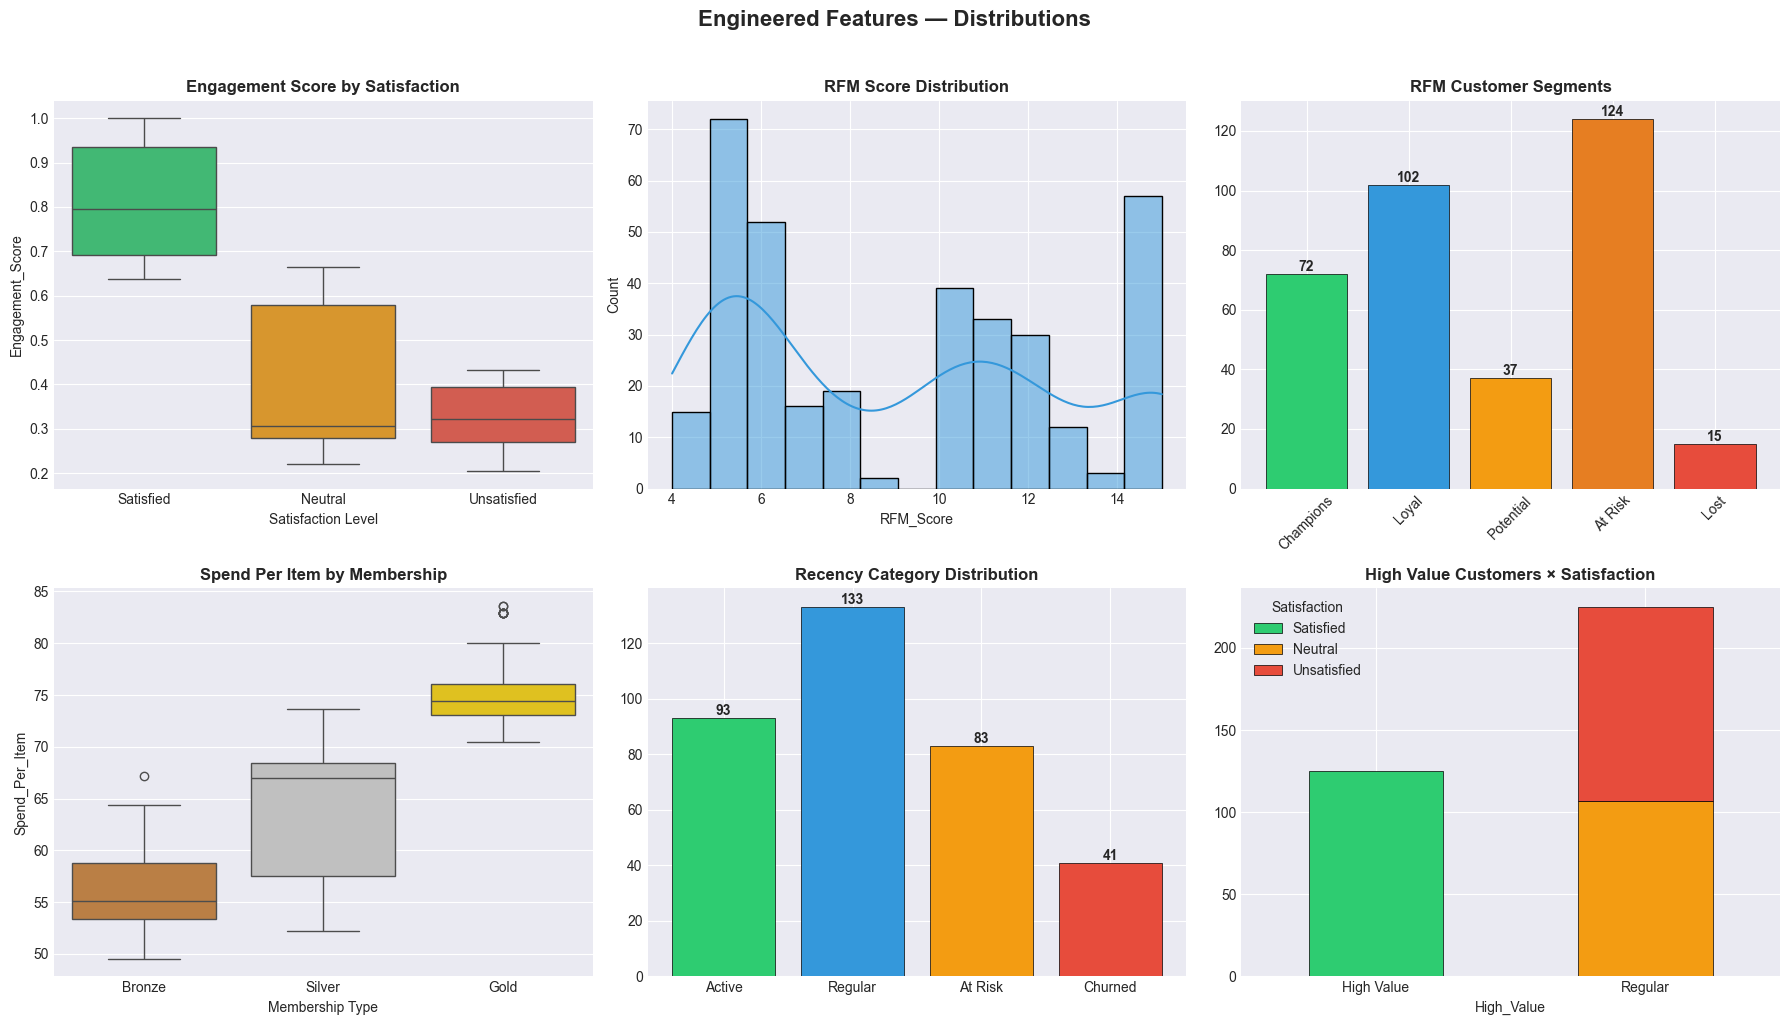

In [23]:
# Visualize engineered features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Engineered Features — Distributions', fontsize=16, fontweight='bold', y=1.02)

# Engagement Score by Satisfaction
sns.boxplot(data=df, x='Satisfaction Level', y='Engagement_Score',
            order=['Satisfied', 'Neutral', 'Unsatisfied'],
            palette=['#2ecc71', '#f39c12', '#e74c3c'], ax=axes[0,0])
axes[0,0].set_title('Engagement Score by Satisfaction', fontweight='bold')

# RFM Score distribution
sns.histplot(df['RFM_Score'], bins=13, kde=True, color='#3498db', ax=axes[0,1], edgecolor='black')
axes[0,1].set_title('RFM Score Distribution', fontweight='bold')

# RFM Segments
seg_order = ['Champions', 'Loyal', 'Potential', 'At Risk', 'Lost']
seg_data = df['RFM_Segment'].value_counts().reindex(seg_order).dropna()
axes[0,2].bar(seg_data.index, seg_data.values, 
               color=['#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c'][:len(seg_data)],
               edgecolor='black', linewidth=0.5)
axes[0,2].set_title('RFM Customer Segments', fontweight='bold')
axes[0,2].tick_params(axis='x', rotation=45)
for i, v in enumerate(seg_data.values):
    axes[0,2].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Spend Per Item by Membership
sns.boxplot(data=df, x='Membership Type', y='Spend_Per_Item',
            order=['Bronze', 'Silver', 'Gold'],
            palette=['#cd7f32', '#c0c0c0', '#ffd700'], ax=axes[1,0])
axes[1,0].set_title('Spend Per Item by Membership', fontweight='bold')

# Recency Category
rec_order = ['Active', 'Regular', 'At Risk', 'Churned']
rec_data = df['Recency_Category'].value_counts().reindex(rec_order)
axes[1,1].bar(rec_data.index, rec_data.values, 
               color=['#2ecc71', '#3498db', '#f39c12', '#e74c3c'],
               edgecolor='black', linewidth=0.5)
axes[1,1].set_title('Recency Category Distribution', fontweight='bold')
for i, v in enumerate(rec_data.values):
    axes[1,1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# High Value vs Satisfaction
ct_hv = pd.crosstab(df['High_Value'].map({0:'Regular', 1:'High Value'}), df['Satisfaction Level'])
ct_hv = ct_hv[['Satisfied', 'Neutral', 'Unsatisfied']]
ct_hv.plot(kind='bar', stacked=True, ax=axes[1,2],
            color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1,2].set_title('High Value Customers × Satisfaction', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=0)
axes[1,2].legend(title='Satisfaction')

plt.tight_layout()
plt.savefig('engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3.6 Encoding Categorical Variables

### 3.6.1 Label Encoding (for Ordinal Variables)

In [24]:
# Label Encoding for ordinal variables
print('='*80)
print('🔧 ENCODING — LABEL ENCODING (Ordinal Variables)')
print('='*80)

# Membership Type — Ordinal: Bronze < Silver < Gold
membership_map = {'Bronze': 0, 'Silver': 1, 'Gold': 2}
df['Membership_Encoded'] = df['Membership Type'].map(membership_map)
print(f'\nMembership Type Encoding:')
print(f'  Bronze → 0, Silver → 1, Gold → 2')
print(df[['Membership Type', 'Membership_Encoded']].drop_duplicates().sort_values('Membership_Encoded'))

# Satisfaction Level — Ordinal: Unsatisfied < Neutral < Satisfied
satisfaction_map = {'Unsatisfied': 0, 'Neutral': 1, 'Satisfied': 2}
df['Satisfaction_Encoded'] = df['Satisfaction Level'].map(satisfaction_map)
print(f'\nSatisfaction Level Encoding:')
print(f'  Unsatisfied → 0, Neutral → 1, Satisfied → 2')
print(df[['Satisfaction Level', 'Satisfaction_Encoded']].drop_duplicates().sort_values('Satisfaction_Encoded'))

🔧 ENCODING — LABEL ENCODING (Ordinal Variables)

Membership Type Encoding:
  Bronze → 0, Silver → 1, Gold → 2
  Membership Type Membership_Encoded
2          Bronze                  0
0            Gold                  2
1          Silver                  1

Satisfaction Level Encoding:
  Unsatisfied → 0, Neutral → 1, Satisfied → 2
  Satisfaction Level Satisfaction_Encoded
1            Neutral                    1
0          Satisfied                    2
2        Unsatisfied                    0


### 3.6.2 Binary Encoding

In [25]:
# Binary Encoding for Gender
print('='*80)
print('🔧 ENCODING — BINARY ENCODING')
print('='*80)

# Gender
gender_map = {'Female': 0, 'Male': 1}
df['Gender_Encoded'] = df['Gender'].map(gender_map)
print(f'\nGender Encoding:')
print(f'  Female → 0, Male → 1')
print(df[['Gender', 'Gender_Encoded']].drop_duplicates())

🔧 ENCODING — BINARY ENCODING

Gender Encoding:
  Female → 0, Male → 1
   Gender Gender_Encoded
0  Female              0
1    Male              1


### 3.6.3 One-Hot Encoding (for Nominal Variables)

In [26]:
# One-Hot Encoding for City (nominal — no natural order)
print('='*80)
print('🔧 ENCODING — ONE-HOT ENCODING (Nominal Variables)')
print('='*80)

# City — One-Hot Encoding
city_dummies = pd.get_dummies(df['City'], prefix='City', dtype=int)
df = pd.concat([df, city_dummies], axis=1)

print(f'\nCity One-Hot Encoded Columns:')
print(city_dummies.columns.tolist())
print(f'\nSample:')
print(df[['City'] + city_dummies.columns.tolist()].head(10))

🔧 ENCODING — ONE-HOT ENCODING (Nominal Variables)

City One-Hot Encoded Columns:
['City_Chicago', 'City_Houston', 'City_Los Angeles', 'City_Miami', 'City_New York', 'City_San Francisco']

Sample:
            City  City_Chicago  City_Houston  City_Los Angeles  City_Miami  \
0       New York             0             0                 0           0   
1    Los Angeles             0             0                 1           0   
2        Chicago             1             0                 0           0   
3  San Francisco             0             0                 0           0   
4          Miami             0             0                 0           1   
5        Houston             0             1                 0           0   
6       New York             0             0                 0           0   
7    Los Angeles             0             0                 1           0   
8        Chicago             1             0                 0           0   
9  San Francisco        

In [27]:
# One-Hot Encoding for RFM Segment
rfm_dummies = pd.get_dummies(df['RFM_Segment'], prefix='Segment', dtype=int)
df = pd.concat([df, rfm_dummies], axis=1)

print(f'RFM Segment One-Hot Encoded Columns:')
print(rfm_dummies.columns.tolist())

# One-Hot for Recency Category
rec_dummies = pd.get_dummies(df['Recency_Category'], prefix='Recency', dtype=int)
df = pd.concat([df, rec_dummies], axis=1)

print(f'\nRecency One-Hot Encoded Columns:')
print(rec_dummies.columns.tolist())

RFM Segment One-Hot Encoded Columns:
['Segment_At Risk', 'Segment_Champions', 'Segment_Lost', 'Segment_Loyal', 'Segment_Potential']

Recency One-Hot Encoded Columns:
['Recency_Active', 'Recency_At Risk', 'Recency_Churned', 'Recency_Regular']


In [28]:
# Summary of all encoded columns
print('='*80)
print('📋 ALL ENCODED COLUMNS')
print('='*80)

encoded_cols = ['Membership_Encoded', 'Satisfaction_Encoded', 'Gender_Encoded', 'Discount Applied'] + \
               city_dummies.columns.tolist() + rfm_dummies.columns.tolist() + rec_dummies.columns.tolist()

for i, col in enumerate(encoded_cols, 1):
    print(f'  {i:>2}. {col}')

print(f'\nTotal encoded columns: {len(encoded_cols)}')
print(f'Current dataset shape: {df.shape}')

📋 ALL ENCODED COLUMNS
   1. Membership_Encoded
   2. Satisfaction_Encoded
   3. Gender_Encoded
   4. Discount Applied
   5. City_Chicago
   6. City_Houston
   7. City_Los Angeles
   8. City_Miami
   9. City_New York
  10. City_San Francisco
  11. Segment_At Risk
  12. Segment_Champions
  13. Segment_Lost
  14. Segment_Loyal
  15. Segment_Potential
  16. Recency_Active
  17. Recency_At Risk
  18. Recency_Churned
  19. Recency_Regular

Total encoded columns: 19
Current dataset shape: (350, 42)


---
## 3.7 Feature Scaling & Normalization

### 3.7.1 Identify Features to Scale

In [29]:
# Identify numerical features that need scaling
print('='*80)
print('🔧 FEATURE SCALING — IDENTIFY FEATURES')
print('='*80)

features_to_scale = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 
                      'Days Since Last Purchase', 'Spend_Per_Item', 'Engagement_Score',
                      'RFM_Score', 'Spend_Rating_Ratio']

print(f'\nFeatures to scale ({len(features_to_scale)}):')
print(f'\n--- Before Scaling — Range Comparison ---')
for col in features_to_scale:
    print(f'  {col:<30}: min={df[col].min():>10.2f}, max={df[col].max():>10.2f}, range={df[col].max()-df[col].min():>10.2f}')

🔧 FEATURE SCALING — IDENTIFY FEATURES

Features to scale (9):

--- Before Scaling — Range Comparison ---
  Age                           : min=     26.00, max=     43.00, range=     17.00
  Total Spend                   : min=    410.80, max=   1520.10, range=   1109.30
  Items Purchased               : min=      7.00, max=     21.00, range=     14.00
  Average Rating                : min=      3.00, max=      4.90, range=      1.90
  Days Since Last Purchase      : min=      9.00, max=     63.00, range=     54.00
  Spend_Per_Item                : min=     49.52, max=     83.59, range=     34.07
  Engagement_Score              : min=      0.21, max=      1.00, range=      0.79
  RFM_Score                     : min=      4.00, max=     15.00, range=     11.00
  Spend_Rating_Ratio            : min=    120.82, max=    316.69, range=    195.87


### 3.7.2 StandardScaler (Z-Score Normalization)

In [30]:
# StandardScaler: mean=0, std=1
print('='*80)
print('🔧 STANDARD SCALER (Z-Score: mean=0, std=1)')
print('='*80)

scaler_standard = StandardScaler()
df_standard = pd.DataFrame(
    scaler_standard.fit_transform(df[features_to_scale]),
    columns=[f'{col}_std' for col in features_to_scale],
    index=df.index
)

print(f'\n--- After Standard Scaling ---')
print(df_standard.describe().round(4).loc[['mean', 'std', 'min', 'max']])

🔧 STANDARD SCALER (Z-Score: mean=0, std=1)

--- After Standard Scaling ---
      Age_std  Total Spend_std  Items Purchased_std  Average Rating_std  \
mean     0.00             0.00                 0.00               -0.00   
std      1.00             1.00                 1.00                1.00   
min     -1.56            -1.20                -1.35               -1.76   
max      1.93             1.87                 2.02                1.52   

      Days Since Last Purchase_std  Spend_Per_Item_std  Engagement_Score_std  \
mean                          0.00                0.00                 -0.00   
std                           1.00                1.00                  1.00   
min                          -1.31               -1.75                 -1.33   
max                           2.71                2.04                  1.86   

      RFM_Score_std  Spend_Rating_Ratio_std  
mean           0.00                   -0.00  
std            1.00                    1.00  
min       

### 3.7.3 MinMaxScaler (0-1 Normalization)

In [31]:
# MinMaxScaler: range [0, 1]
print('='*80)
print('🔧 MIN-MAX SCALER (Range: 0 to 1)')
print('='*80)

scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(
    scaler_minmax.fit_transform(df[features_to_scale]),
    columns=[f'{col}_mm' for col in features_to_scale],
    index=df.index
)

print(f'\n--- After Min-Max Scaling ---')
print(df_minmax.describe().round(4).loc[['mean', 'std', 'min', 'max']])

🔧 MIN-MAX SCALER (Range: 0 to 1)

--- After Min-Max Scaling ---
      Age_mm  Total Spend_mm  Items Purchased_mm  Average Rating_mm  \
mean    0.45            0.39                0.40               0.54   
std     0.29            0.33                0.30               0.31   
min     0.00            0.00                0.00               0.00   
max     1.00            1.00                1.00               1.00   

      Days Since Last Purchase_mm  Spend_Per_Item_mm  Engagement_Score_mm  \
mean                         0.33               0.46                 0.42   
std                          0.25               0.26                 0.31   
min                          0.00               0.00                 0.00   
max                          1.00               1.00                 1.00   

      RFM_Score_mm  Spend_Rating_Ratio_mm  
mean          0.46                   0.42  
std           0.34                   0.30  
min           0.00                   0.00  
max           1.00

### 3.7.4 RobustScaler (Outlier-Resistant)

In [32]:
# RobustScaler: uses median and IQR (resistant to outliers)
print('='*80)
print('🔧 ROBUST SCALER (Uses Median & IQR — Outlier Resistant)')
print('='*80)

scaler_robust = RobustScaler()
df_robust = pd.DataFrame(
    scaler_robust.fit_transform(df[features_to_scale]),
    columns=[f'{col}_rob' for col in features_to_scale],
    index=df.index
)

print(f'\n--- After Robust Scaling ---')
print(df_robust.describe().round(4).loc[['mean', 'std', 'min', 'max']])

🔧 ROBUST SCALER (Uses Median & IQR — Outlier Resistant)

--- After Robust Scaling ---
      Age_rob  Total Spend_rob  Items Purchased_rob  Average Rating_rob  \
mean     0.16             0.11                 0.10               -0.08   
std      0.70             0.55                 0.69                0.58   
min     -0.93            -0.55                -0.83               -1.10   
max      1.50             1.13                 1.50                0.80   

      Days Since Last Purchase_rob  Spend_Per_Item_rob  Engagement_Score_rob  \
mean                          0.16               -0.12                 -0.06   
std                           0.58                0.57                  0.62   
min                          -0.61               -1.12                 -0.88   
max                           1.74                1.06                  1.09   

      RFM_Score_rob  Spend_Rating_Ratio_rob  
mean           0.01                    0.16  
std            0.62                    0.59  

### 3.7.5 Scaling Comparison Visualization

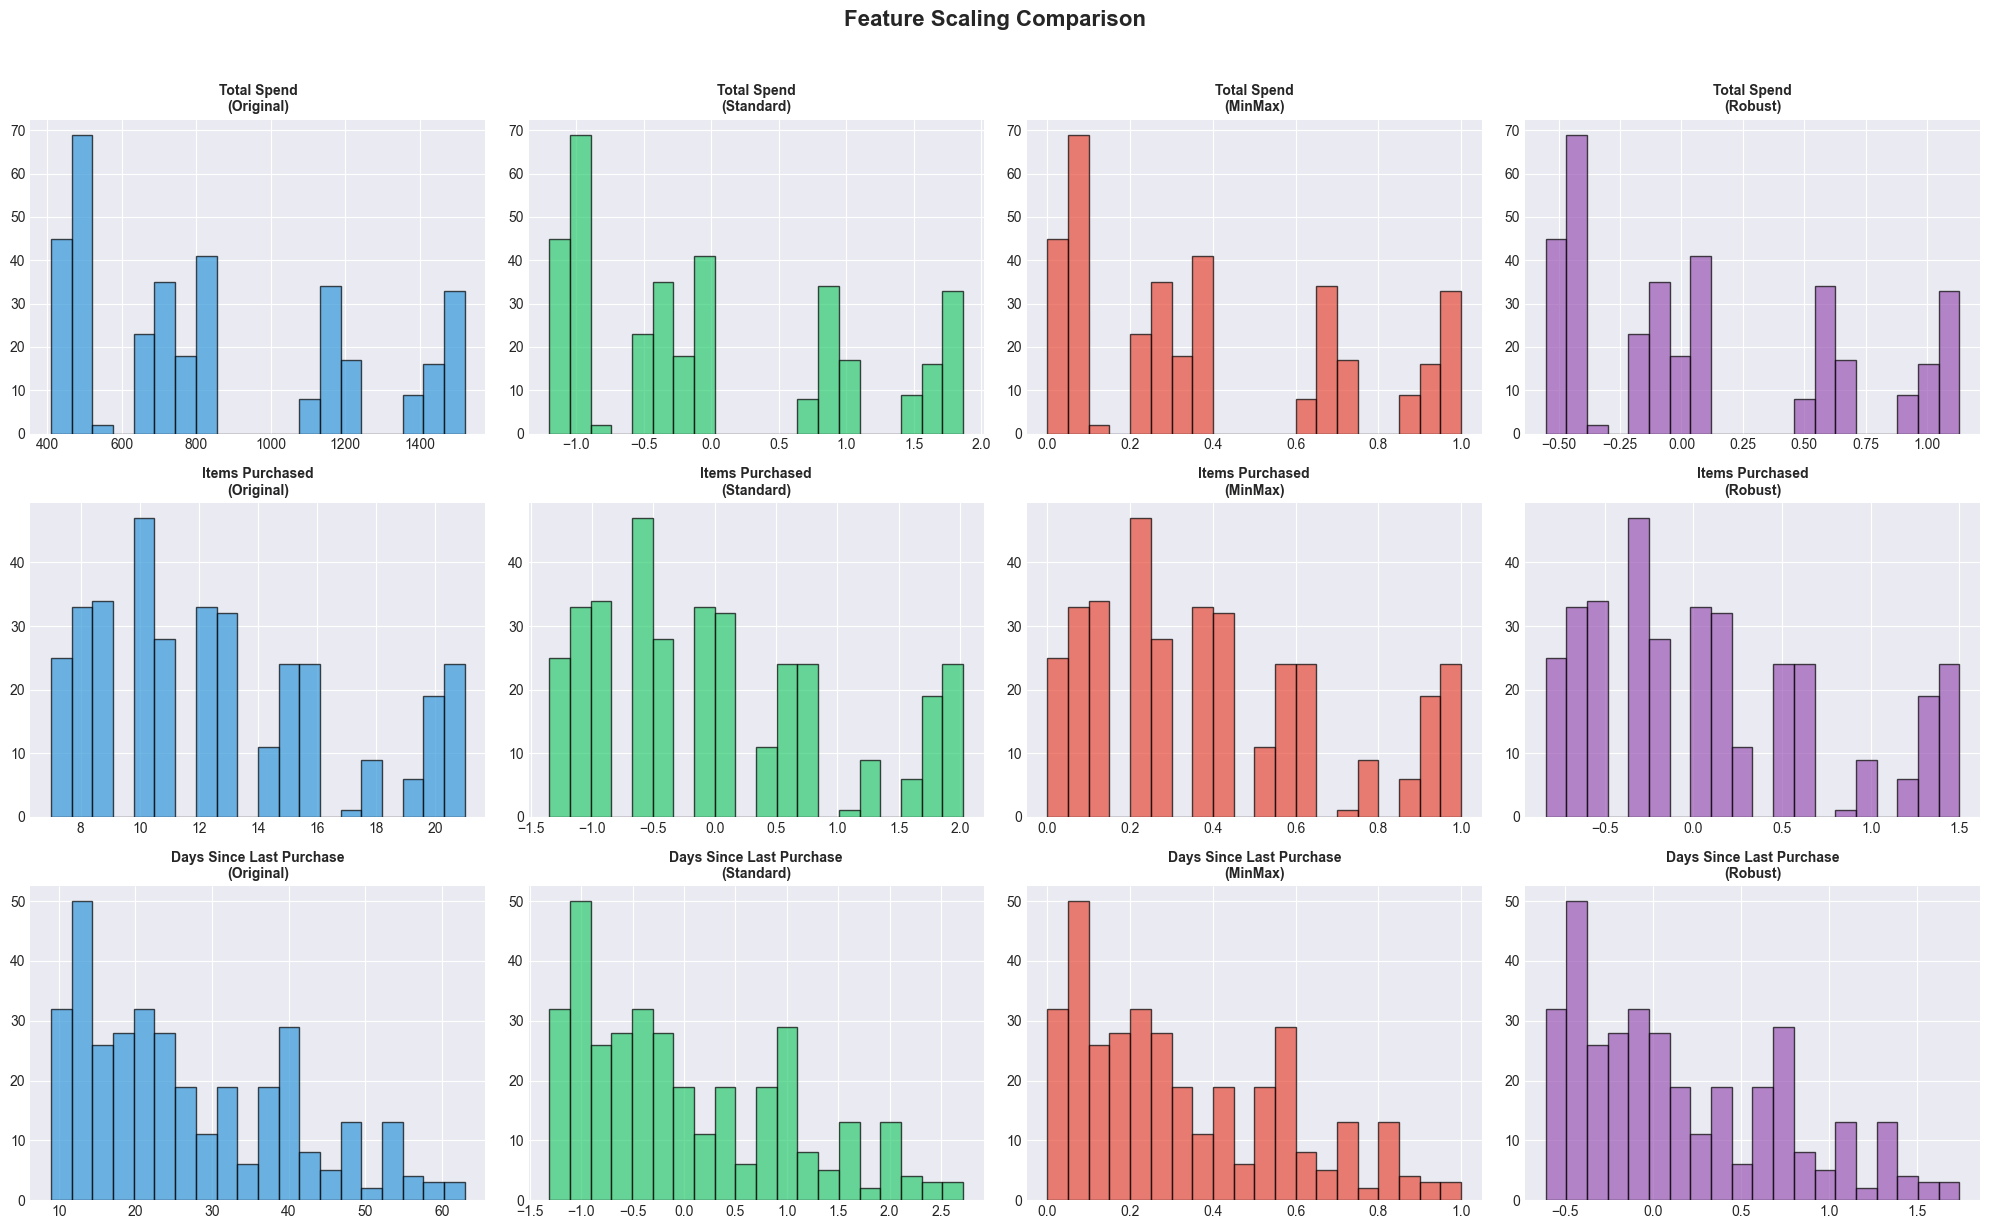

In [33]:
# Visualize scaling comparison for key features
compare_features = ['Total Spend', 'Items Purchased', 'Days Since Last Purchase']

fig, axes = plt.subplots(len(compare_features), 4, figsize=(20, 4*len(compare_features)))
fig.suptitle('Feature Scaling Comparison', fontsize=16, fontweight='bold', y=1.02)

for i, feat in enumerate(compare_features):
    # Original
    axes[i, 0].hist(df[feat], bins=20, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i, 0].set_title(f'{feat}\n(Original)', fontweight='bold', fontsize=10)
    
    # Standard Scaled
    axes[i, 1].hist(df_standard[f'{feat}_std'], bins=20, color='#2ecc71', edgecolor='black', alpha=0.7)
    axes[i, 1].set_title(f'{feat}\n(Standard)', fontweight='bold', fontsize=10)
    
    # MinMax Scaled
    axes[i, 2].hist(df_minmax[f'{feat}_mm'], bins=20, color='#e74c3c', edgecolor='black', alpha=0.7)
    axes[i, 2].set_title(f'{feat}\n(MinMax)', fontweight='bold', fontsize=10)
    
    # Robust Scaled
    axes[i, 3].hist(df_robust[f'{feat}_rob'], bins=20, color='#9b59b6', edgecolor='black', alpha=0.7)
    axes[i, 3].set_title(f'{feat}\n(Robust)', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Add the Standard Scaled features to the main dataframe (most commonly used)
print('='*80)
print('✅ ADDING STANDARD SCALED FEATURES TO DATASET')
print('='*80)

df = pd.concat([df, df_standard], axis=1)
print(f'\nDataset shape after adding scaled features: {df.shape}')
print(f'Scaled columns added: {df_standard.columns.tolist()}')

✅ ADDING STANDARD SCALED FEATURES TO DATASET

Dataset shape after adding scaled features: (350, 51)
Scaled columns added: ['Age_std', 'Total Spend_std', 'Items Purchased_std', 'Average Rating_std', 'Days Since Last Purchase_std', 'Spend_Per_Item_std', 'Engagement_Score_std', 'RFM_Score_std', 'Spend_Rating_Ratio_std']


---
## 3.8 Feature Selection

### 3.8.1 Correlation with Target Variable

In [35]:
# Correlation of numerical features with Satisfaction (encoded)
print('='*80)
print('📊 CORRELATION WITH TARGET — SATISFACTION LEVEL (Encoded)')
print('='*80)

numerical_features = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
                       'Days Since Last Purchase', 'Discount Applied',
                       'Spend_Per_Item', 'Engagement_Score', 'RFM_Score',
                       'Spend_Rating_Ratio', 'High_Value', 'Churn_Risk',
                       'Membership_Encoded', 'Gender_Encoded']

target_corr = df[numerical_features + ['Satisfaction_Encoded']].corr()['Satisfaction_Encoded'].drop('Satisfaction_Encoded')
target_corr = target_corr.sort_values(ascending=False)

print(f'\n--- Correlation with Satisfaction (sorted by |r|) ---')
for feat, corr_val in target_corr.items():
    bar = '█' * int(abs(corr_val) * 40)
    sign = '+' if corr_val > 0 else '-'
    strength = 'STRONG' if abs(corr_val) > 0.5 else ('MODERATE' if abs(corr_val) > 0.3 else 'WEAK')
    print(f'  {feat:<30} {sign}{abs(corr_val):.4f}  {bar}  [{strength}]')

📊 CORRELATION WITH TARGET — SATISFACTION LEVEL (Encoded)

--- Correlation with Satisfaction (sorted by |r|) ---
  High_Value                     +0.8769  ███████████████████████████████████  [STRONG]
  Engagement_Score               +0.8216  ████████████████████████████████  [STRONG]
  Spend_Per_Item                 +0.8065  ████████████████████████████████  [STRONG]
  Spend_Rating_Ratio             +0.8064  ████████████████████████████████  [STRONG]
  RFM_Score                      +0.8060  ████████████████████████████████  [STRONG]
  Total Spend                    +0.7991  ███████████████████████████████  [STRONG]
  Membership_Encoded             +0.7440  █████████████████████████████  [STRONG]
  Average Rating                 +0.6974  ███████████████████████████  [STRONG]
  Items Purchased                +0.6957  ███████████████████████████  [STRONG]
  Gender_Encoded                 +0.0446  █  [WEAK]
  Discount Applied               -0.4150  ████████████████  [MODERATE]
  Age      

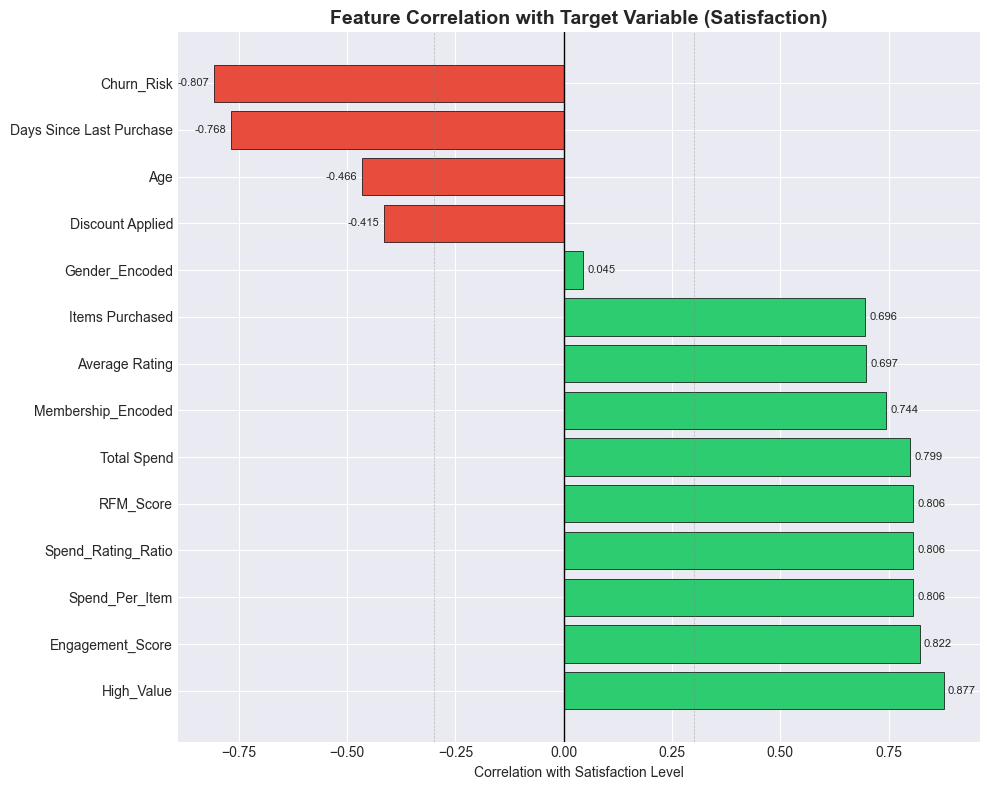

In [36]:
# Visualize correlation with target
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Correlation with Satisfaction Level')
ax.set_title('Feature Correlation with Target Variable (Satisfaction)', fontweight='bold', fontsize=14)
ax.axvline(x=0, color='black', linewidth=1)
ax.axvline(x=0.3, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.axvline(x=-0.3, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

for i, v in enumerate(target_corr.values):
    ax.text(v + 0.01 if v > 0 else v - 0.01, i, f'{v:.3f}', 
            va='center', ha='left' if v > 0 else 'right', fontsize=8)

plt.tight_layout()
plt.savefig('feature_correlation_target.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.8.2 Feature Correlation Heatmap (Multicollinearity Check)

📊 MULTICOLLINEARITY CHECK


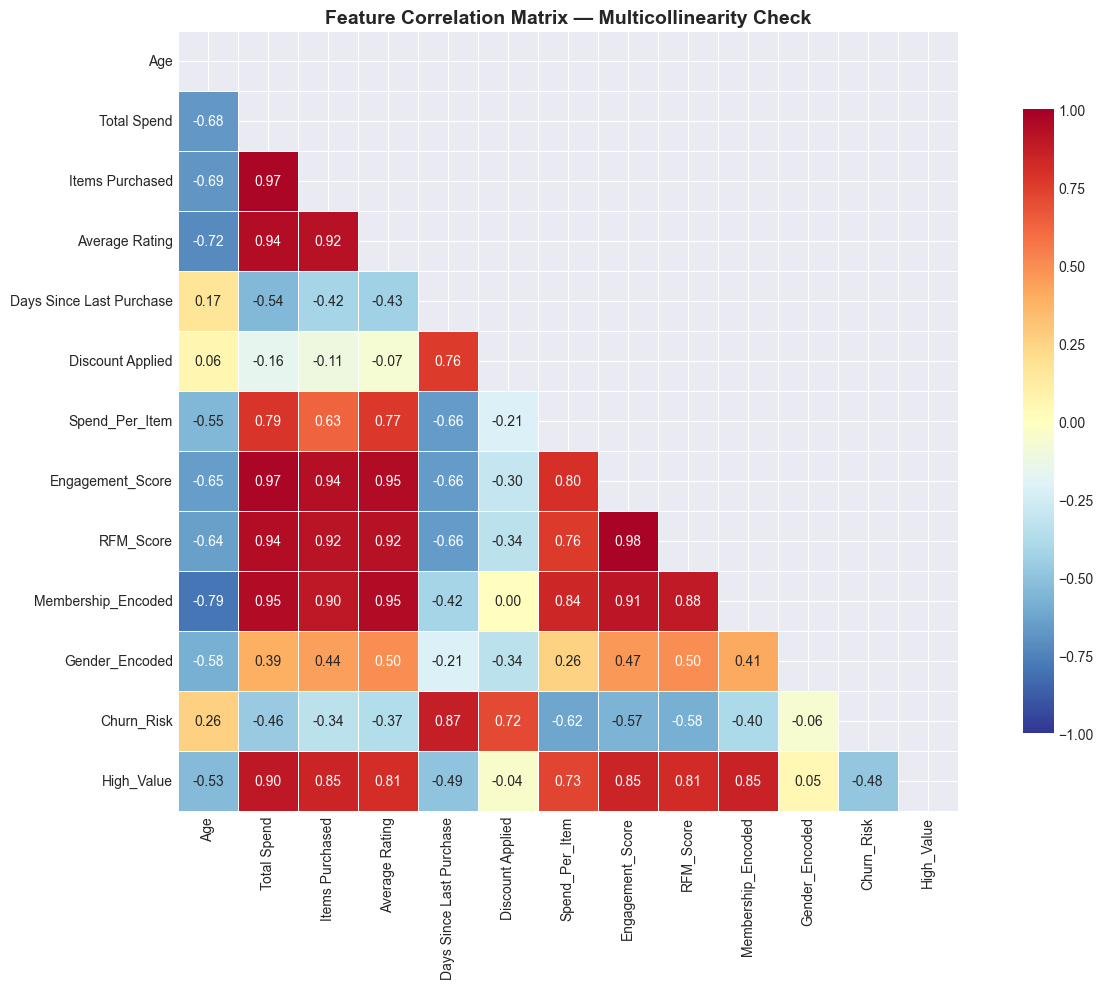


--- Highly Correlated Pairs (|r| > 0.7) ---
               Feature 1          Feature 2  Correlation
        Engagement_Score          RFM_Score         0.98
             Total Spend    Items Purchased         0.97
             Total Spend   Engagement_Score         0.97
          Average Rating Membership_Encoded         0.95
          Average Rating   Engagement_Score         0.95
             Total Spend Membership_Encoded         0.95
             Total Spend          RFM_Score         0.94
             Total Spend     Average Rating         0.94
         Items Purchased   Engagement_Score         0.94
          Average Rating          RFM_Score         0.92
         Items Purchased     Average Rating         0.92
         Items Purchased          RFM_Score         0.92
        Engagement_Score Membership_Encoded         0.91
         Items Purchased Membership_Encoded         0.90
             Total Spend         High_Value         0.90
               RFM_Score Membership_Encoded

In [37]:
# Check for multicollinearity among features
print('='*80)
print('📊 MULTICOLLINEARITY CHECK')
print('='*80)

selected_features = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
                      'Days Since Last Purchase', 'Discount Applied',
                      'Spend_Per_Item', 'Engagement_Score', 'RFM_Score',
                      'Membership_Encoded', 'Gender_Encoded', 'Churn_Risk', 'High_Value']

corr_features = df[selected_features].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_features, dtype=bool))
sns.heatmap(corr_features, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0,
            mask=mask, square=True, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix — Multicollinearity Check', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.savefig('multicollinearity_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Identify highly correlated pairs
print('\n--- Highly Correlated Pairs (|r| > 0.7) ---')
high_corr_pairs = []
for i in range(len(corr_features.columns)):
    for j in range(i+1, len(corr_features.columns)):
        if abs(corr_features.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Feature 1': corr_features.columns[i],
                'Feature 2': corr_features.columns[j],
                'Correlation': round(corr_features.iloc[i, j], 4)
            })

if high_corr_pairs:
    hc_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', ascending=False)
    print(hc_df.to_string(index=False))
    print(f'\n⚠️ Consider removing one feature from each highly correlated pair to avoid multicollinearity.')
else:
    print('✅ No highly correlated pairs found (|r| > 0.7). No multicollinearity issues.')

### 3.8.3 Final Feature Selection

In [38]:
# Define feature sets for different modeling tasks
print('='*80)
print('📋 FINAL FEATURE SETS FOR MODELING')
print('='*80)

# Feature set for Satisfaction Prediction
features_satisfaction = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
                          'Days Since Last Purchase', 'Discount Applied',
                          'Membership_Encoded', 'Gender_Encoded',
                          'Spend_Per_Item', 'Engagement_Score']

# Feature set for Customer Clustering
features_clustering = ['Total Spend_std', 'Items Purchased_std', 'Average Rating_std',
                        'Days Since Last Purchase_std', 'Engagement_Score_std']

# Target variable
target = 'Satisfaction_Encoded'

print(f'\n🎯 TARGET VARIABLE: {target}')
print(f'   Values: 0=Unsatisfied, 1=Neutral, 2=Satisfied')

print(f'\n📊 Feature Set 1 — Satisfaction Prediction ({len(features_satisfaction)} features):')
for i, f in enumerate(features_satisfaction, 1):
    print(f'   {i:>2}. {f}')

print(f'\n📊 Feature Set 2 — Customer Clustering ({len(features_clustering)} features):')
for i, f in enumerate(features_clustering, 1):
    print(f'   {i:>2}. {f}')

📋 FINAL FEATURE SETS FOR MODELING

🎯 TARGET VARIABLE: Satisfaction_Encoded
   Values: 0=Unsatisfied, 1=Neutral, 2=Satisfied

📊 Feature Set 1 — Satisfaction Prediction (10 features):
    1. Age
    2. Total Spend
    3. Items Purchased
    4. Average Rating
    5. Days Since Last Purchase
    6. Discount Applied
    7. Membership_Encoded
    8. Gender_Encoded
    9. Spend_Per_Item
   10. Engagement_Score

📊 Feature Set 2 — Customer Clustering (5 features):
    1. Total Spend_std
    2. Items Purchased_std
    3. Average Rating_std
    4. Days Since Last Purchase_std
    5. Engagement_Score_std


---
## 3.9 Train-Test Split

In [39]:
# Prepare data for modeling
print('='*80)
print('✂️ TRAIN-TEST SPLIT')
print('='*80)

X = df[features_satisfaction]
y = df[target]

print(f'\nFeature Matrix (X): {X.shape}')
print(f'Target Vector (y) : {y.shape}')
print(f'\nTarget Distribution:')
print(y.value_counts().sort_index())

# 80-20 split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n--- Split Results ---')
print(f'  Training set : {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Testing set  : {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

print(f'\n--- Target Distribution (Training) ---')
train_dist = y_train.value_counts(normalize=True).sort_index() * 100
for val, pct in train_dist.items():
    label = {0: 'Unsatisfied', 1: 'Neutral', 2: 'Satisfied'}[val]
    print(f'  {label:<15}: {pct:.1f}%')

print(f'\n--- Target Distribution (Testing) ---')
test_dist = y_test.value_counts(normalize=True).sort_index() * 100
for val, pct in test_dist.items():
    label = {0: 'Unsatisfied', 1: 'Neutral', 2: 'Satisfied'}[val]
    print(f'  {label:<15}: {pct:.1f}%')

print(f'\n✅ Stratified split ensures proportional representation in both sets!')

✂️ TRAIN-TEST SPLIT

Feature Matrix (X): (350, 10)
Target Vector (y) : (350,)

Target Distribution:
Satisfaction_Encoded
1    107
2    125
0    118
Name: count, dtype: int64

--- Split Results ---
  Training set : 280 samples (80%)
  Testing set  : 70 samples (20%)

--- Target Distribution (Training) ---
  Neutral        : 30.7%
  Satisfied      : 35.7%
  Unsatisfied    : 33.6%

--- Target Distribution (Testing) ---
  Neutral        : 30.0%
  Satisfied      : 35.7%
  Unsatisfied    : 34.3%

✅ Stratified split ensures proportional representation in both sets!


---
## 3.10 Save Prepared Data

In [40]:
# Save the cleaned and prepared dataset
print('='*80)
print('💾 SAVING PREPARED DATASETS')
print('='*80)

# Full prepared dataset
df.to_csv('prepared_data.csv', index=False)
print(f'\n✅ Full prepared dataset saved: prepared_data.csv')
print(f'   Shape: {df.shape}')

# Training set
train_data = pd.concat([X_train, y_train], axis=1)
train_data.to_csv('train_data.csv', index=False)
print(f'\n✅ Training set saved: train_data.csv')
print(f'   Shape: {train_data.shape}')

# Testing set
test_data = pd.concat([X_test, y_test], axis=1)
test_data.to_csv('test_data.csv', index=False)
print(f'\n✅ Testing set saved: test_data.csv')
print(f'   Shape: {test_data.shape}')

💾 SAVING PREPARED DATASETS

✅ Full prepared dataset saved: prepared_data.csv
   Shape: (350, 51)

✅ Training set saved: train_data.csv
   Shape: (280, 11)

✅ Testing set saved: test_data.csv
   Shape: (70, 11)


---
## 3.11 Final Dataset Overview

In [41]:
# Final overview of prepared dataset
print('='*80)
print('📋 FINAL DATASET OVERVIEW')
print('='*80)

print(f'\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Missing Values: {df.isnull().sum().sum()}')
print(f'Duplicates: {df.duplicated().sum()}')

print(f'\n--- All Columns ({df.shape[1]}) ---')
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    category = 'Original' if col in df_original.columns else 'Engineered'
    print(f'  {i:>2}. {col:<35} [{dtype:<10}]  ({category})')

print(f'\n--- Column Count by Category ---')
orig_count = sum(1 for col in df.columns if col in df_original.columns)
new_count = df.shape[1] - orig_count
print(f'  Original columns  : {orig_count}')
print(f'  Engineered columns: {new_count}')
print(f'  Total columns     : {df.shape[1]}')

📋 FINAL DATASET OVERVIEW

Dataset Shape: 350 rows × 51 columns
Missing Values: 0
Duplicates: 0

--- All Columns (51) ---
   1. Customer ID                         [int64     ]  (Original)
   2. Gender                              [category  ]  (Original)
   3. Age                                 [int64     ]  (Original)
   4. City                                [category  ]  (Original)
   5. Membership Type                     [category  ]  (Original)
   6. Total Spend                         [float64   ]  (Original)
   7. Items Purchased                     [int64     ]  (Original)
   8. Average Rating                      [float64   ]  (Original)
   9. Discount Applied                    [int64     ]  (Original)
  10. Days Since Last Purchase            [int64     ]  (Original)
  11. Satisfaction Level                  [category  ]  (Original)
  12. Spend_Per_Item                      [float64   ]  (Engineered)
  13. Age_Group                           [category  ]  (Engineered)
  14

In [42]:
# Final sanity check
print('='*80)
print('✅ DATA PREPARATION — FINAL SANITY CHECK')
print('='*80)

checks = [
    ('No missing values', df.isnull().sum().sum() == 0),
    ('No full row duplicates', df.duplicated().sum() == 0),
    ('Target encoded (0,1,2)', set(df['Satisfaction_Encoded'].unique()) == {0, 1, 2}),
    ('Gender encoded (0,1)', set(df['Gender_Encoded'].unique()) == {0, 1}),
    ('Membership encoded (0,1,2)', set(df['Membership_Encoded'].unique()) == {0, 1, 2}),
    ('Discount Applied is int', df['Discount Applied'].dtype in ['int64', 'int32']),
    ('Engagement Score exists', 'Engagement_Score' in df.columns),
    ('RFM Score exists', 'RFM_Score' in df.columns),
    ('Scaled features exist', 'Total Spend_std' in df.columns),
    ('Train/test files saved', True),
]

all_pass = True
for check_name, result in checks:
    status = '✅ PASS' if result else '❌ FAIL'
    if not result:
        all_pass = False
    print(f'  {status} — {check_name}')

print(f'\n{"🎉 ALL CHECKS PASSED!" if all_pass else "⚠️ SOME CHECKS FAILED!"}')

✅ DATA PREPARATION — FINAL SANITY CHECK
  ✅ PASS — No missing values
  ✅ PASS — No full row duplicates
  ✅ PASS — Target encoded (0,1,2)
  ✅ PASS — Gender encoded (0,1)
  ✅ PASS — Membership encoded (0,1,2)
  ✅ PASS — Discount Applied is int
  ✅ PASS — Engagement Score exists
  ✅ PASS — RFM Score exists
  ✅ PASS — Scaled features exist
  ✅ PASS — Train/test files saved

🎉 ALL CHECKS PASSED!


In [43]:
print('='*80)
print('📋 DATA PREPARATION SUMMARY')
print('='*80)

print('''
╔══════════════════════════════════════════════════════════════════════════╗
║                    WHAT WAS DONE                                       ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. MISSING VALUES                                                     ║
║     → 2 missing Satisfaction Level values imputed using mode           ║
║       by Membership Type                                               ║
║                                                                        ║
║  2. DATA TYPE CORRECTIONS                                              ║
║     → Discount Applied: string → int (0/1)                            ║
║     → Categorical columns → category dtype                            ║
║                                                                        ║
║  3. FEATURE ENGINEERING (13 new features)                              ║
║     → Spend_Per_Item, Age_Group, Spend_Category                       ║
║     → Recency_Category, Churn_Risk, Engagement_Score                  ║
║     → R/F/M Scores, RFM_Score, RFM_Segment                           ║
║     → Spend_Rating_Ratio, High_Value                                  ║
║                                                                        ║
║  4. ENCODING                                                           ║
║     → Label Encoding: Membership (0-2), Satisfaction (0-2)            ║
║     → Binary Encoding: Gender (0/1)                                   ║
║     → One-Hot Encoding: City, RFM Segment, Recency Category           ║
║                                                                        ║
║  5. FEATURE SCALING                                                    ║
║     → StandardScaler (Z-score) — Primary                              ║
║     → MinMaxScaler (0-1) — Compared                                   ║
║     → RobustScaler (IQR) — Compared                                   ║
║                                                                        ║
║  6. FEATURE SELECTION                                                  ║
║     → Correlation with target analysis                                ║
║     → Multicollinearity check                                          ║
║     → 2 feature sets defined (prediction + clustering)                ║
║                                                                        ║
║  7. TRAIN-TEST SPLIT                                                   ║
║     → 80/20 stratified split                                          ║
║     → Saved train_data.csv and test_data.csv                          ║
║                                                                        ║
╚══════════════════════════════════════════════════════════════════════════╝
''')

print('='*80)
print('✅ PHASE 3: DATA PREPARATION — COMPLETE')
print('Next → Phase 4: Modeling')
print('='*80)

📋 DATA PREPARATION SUMMARY

╔══════════════════════════════════════════════════════════════════════════╗
║                    WHAT WAS DONE                                       ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  1. MISSING VALUES                                                     ║
║     → 2 missing Satisfaction Level values imputed using mode           ║
║       by Membership Type                                               ║
║                                                                        ║
║  2. DATA TYPE CORRECTIONS                                              ║
║     → Discount Applied: string → int (0/1)                            ║
║     → Categorical columns → category dtype                            ║
║                                                                        ║
║  3. FEATURE ENGINEERING (13 new features)                           

---
## 📝 Phase 3 Conclusion

In this phase, we performed comprehensive **data preparation**:

### ✅ Data Cleaning
- Imputed 2 missing Satisfaction Level values using mode-by-group strategy
- Verified no duplicates
- Fixed data types (Discount Applied, categorical columns)

### ✅ Feature Engineering (13 New Features)
- **Spend_Per_Item** — Average price per item purchased
- **Age_Group** — Binned age into 4 groups
- **Spend_Category** — Low / Medium / High spender classification
- **Recency_Category** — Active / Regular / At Risk / Churned
- **Churn_Risk** — Binary churn risk flag
- **Engagement_Score** — Composite metric combining rating, items, recency
- **R_Score, F_Score, M_Score** — Individual RFM quintile scores
- **RFM_Score** — Combined RFM score (3-15)
- **RFM_Segment** — Customer segment based on RFM score
- **Spend_Rating_Ratio** — Spend efficiency metric
- **High_Value** — Binary high-value customer flag

### ✅ Encoding
- Label encoding for ordinal variables (Membership, Satisfaction)
- Binary encoding for Gender
- One-hot encoding for City, RFM Segment, Recency Category

### ✅ Scaling
- Compared StandardScaler, MinMaxScaler, RobustScaler
- Applied StandardScaler as primary

### ✅ Feature Selection & Split
- Correlation analysis with target variable
- Multicollinearity check
- 80/20 stratified train-test split
- Saved 3 output files: prepared_data.csv, train_data.csv, test_data.csv

### 🔜 Next Steps → Phase 4: Modeling
- K-Means Clustering for customer segmentation
- Classification models for satisfaction prediction
- Model comparison and evaluation